## 1. 2H-Ge nanowire maximum rashba splitting

Plot saved as combined_band_splitting_grid_N100_L300_kx0.001.svg


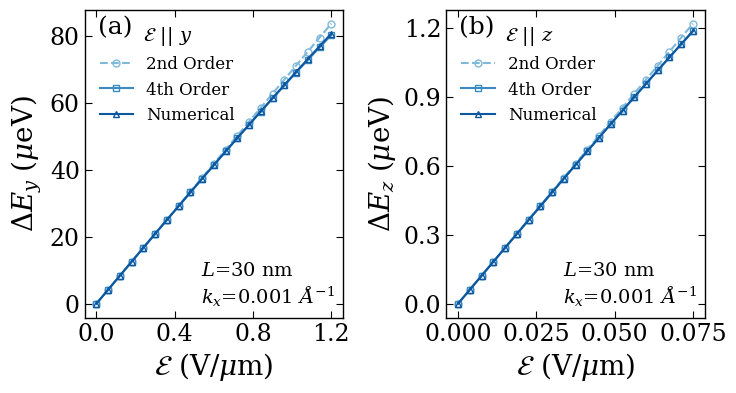

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# ==============================================================
#                      GENERAL PARAMETERS
# ==============================================================


N = 100
L = 300
size = L
kx = 0.001
emax_y = 1.200
emax_z = 0.075
# Ef_values_y = np.linspace(0.0, emax_y, 21)
# Ef_values_z = np.linspace(0.0, emax_z, 21)
# ==================================================
# Global plot settings
# ==================================================
plt.rcParams.update({
    "figure.figsize": [8, 8],
    "font.family": "Serif",
    "mathtext.fontset": "dejavuserif",

    "axes.linewidth": 1.0,
    "axes.labelsize": 20,
    "xtick.labelsize": 17,
    "ytick.labelsize": 17,
    "legend.fontsize": 15,

    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,

    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
})

# ==============================================================
#                      DATA LOADING
# ==============================================================



datay_pb = np.loadtxt(
    f"Pymablock_Y_kx{kx}_emax_{emax_y:.3f}_N{N}_L{L}.dat",
    skiprows=1
)

datay_num = np.loadtxt(
    f"numerical_splitting_N{N}_L{L}_emax{emax_y:.3f}_y.dat",
    skiprows=1
)

Efield_split_y = datay_pb[:, 0]
alpha_y = datay_pb[:,1] * 100 #meV nm
split_pb_2nd_y = datay_pb[:, 2]
split_pb_4th_y = datay_pb[:, 3]
split_num_y = datay_num[:, 3]

dataz_pb = np.loadtxt(
    f"Pymablock_Z_kx{kx}_emax_{emax_z:.3f}_N{N}_L{L}.dat",
    skiprows=1
)

dataz_num = np.loadtxt(
    f"numerical_splitting_N{N}_L{L}_emax{emax_z:.3f}_z.dat",
    skiprows=1
)

Efield_split_z = dataz_pb[:, 0]
alpha_z = dataz_pb[:,1] * 100 #meV nm
split_pb_2nd_z = dataz_pb[:, 2]
split_pb_4th_z = dataz_pb[:, 3]
split_num_z = dataz_num[:, 3]


# ==============================================================
#                      COLORS
# ==============================================================

cmap_bands = plt.cm.Blues
# colors_bands = cmap_bands(np.linspace(0.45, 0.85, len(efields_um)))

cmap_blue_split = plt.cm.Blues
cmap_red_split = plt.cm.Reds

blue_colors_split = cmap_blue_split([0.45, 0.65, 0.85])
red_colors_split = cmap_red_split([0.45, 0.65, 0.85])

# ==============================================================
#                      HELPERS
# ==============================================================

def format_ax(ax):
    ax.tick_params(
        direction="in",
        bottom=True,
        top=True,
        left=True,
        right=True
    )
    # ax.minorticks_on()



# ==============================================================
#                      CREATE 1x2 GRID
# ==============================================================

fig, axs = plt.subplots(
    1, 2,
    sharex="col",
    sharey="none",
    figsize=(8, 4)
)

plt.subplots_adjust(wspace=0.40, hspace=0.10)

# ==============================================================
#                      ROW 0: E || Y
# ==============================================================



ax_split_y = axs[0]

ax_split_y.plot(
    Efield_split_y,
    split_pb_2nd_y,
    marker="o",
    linestyle="--",
    color=blue_colors_split[0],
    label="2nd Order",
    markersize=5,
    markerfacecolor="none",
    markeredgewidth=1.0,
    linewidth=1.5
)

ax_split_y.plot(
    Efield_split_y,
    split_pb_4th_y,
    marker="s",
    linestyle="-",
    color=blue_colors_split[1],
    label="4th Order",
    markersize=5,
    markerfacecolor="none",
    markeredgewidth=1.0,
    linewidth=1.5
)

ax_split_y.plot(
    Efield_split_y,
    split_num_y,
    marker="^",
    linestyle="-",
    color=blue_colors_split[2],
    label="Numerical",
    markersize=5,
    markerfacecolor="none",
    markeredgewidth=1.0,
    linewidth=1.5
)

ax_split_y.set_ylabel(r"$\Delta E_y$ ($\mu$eV)")
ax_split_y.set_xlabel(r"$\mathcal{E}$ (V/$\mu$m)")

ax_split_y.legend(
    frameon=False,
    fontsize=12,
    title=r"$\mathcal{E}$ || $y$",
    title_fontsize=14,
    loc="best"
)

ax_split_y.text(
    0.05,
    0.92,
    "(a)",
    transform=ax_split_y.transAxes,
    fontsize=18
)

ax_split_y.text(
    0.45,
    0.05,
    f"$L$={int(L/10)} nm\n$k_x$={kx}" r" $\AA^{-1}$",
    transform=ax_split_y.transAxes,
    fontsize=14
)



format_ax(ax_split_y)

# ==============================================================
#                      ROW 1: E || Z
# ==============================================================


ax_split_z = axs[1]

ax_split_z.plot(
    Efield_split_z,
    split_pb_2nd_z,
    marker="o",
    linestyle="--",
    color=blue_colors_split[0],
    label="2nd Order",
    markersize=5,
    markerfacecolor="none",
    markeredgewidth=1.0,
    linewidth=1.5
)

ax_split_z.plot(
    Efield_split_z,
    split_pb_4th_z,
    marker="s",
    linestyle="-",
    color=blue_colors_split[1],
    label="4th Order",
    markersize=5,
    markerfacecolor="none",
    markeredgewidth=1.0,
    linewidth=1.5
)

ax_split_z.plot(
    Efield_split_z,
    split_num_z,
    marker="^",
    linestyle="-",
    color=blue_colors_split[2],
    label="Numerical",
    markersize=5,
    markerfacecolor="none",
    markeredgewidth=1.0,
    linewidth=1.5
)

ax_split_z.set_ylabel(r"$\Delta E_z$ ($\mu$eV)")
ax_split_z.set_xlabel(r"$\mathcal{E}$ (V/$\mu$m)")

ax_split_z.legend(
    frameon=False,
    fontsize=12,
    title=r"$\mathcal{E}$ || $z$",
    title_fontsize=14,
    loc="best"
)

ax_split_z.text(
    0.05,
    0.92,
    "(b)",
    transform=ax_split_z.transAxes,
    fontsize=18
)

ax_split_z.text(
    0.45,
    0.05,
    f"$L$={int(L/10)} nm\n$k_x$={kx}" r" $\AA^{-1}$",
    transform=ax_split_z.transAxes,
    fontsize=14
)
format_ax(ax_split_z)

# ==============================================================
#                      TICKS
# ==============================================================

ax_split_y.yaxis.set_major_locator(
    MaxNLocator(nbins=5, prune="upper")
)

ax_split_z.yaxis.set_major_locator(
    MaxNLocator(nbins=5)
)

ax_split_y.xaxis.set_major_locator(
    MaxNLocator(nbins=4)
)

ax_split_z.xaxis.set_major_locator(
    MaxNLocator(nbins=4)
)

# ==============================================================
#                      SAVE AND SHOW
# ==============================================================


save_name = f"combined_band_splitting_grid_N{N}_L{L}_kx{kx}.pdf"
plt.savefig(save_name, dpi=300, bbox_inches="tight")

save_name = f"combined_band_splitting_grid_N{N}_L{L}_kx{kx}.svg"
plt.savefig(save_name, dpi=300, bbox_inches="tight")

print(f"Plot saved as {save_name}")

plt.show()



## 2. Maximum Rashba splitting and spin orbit length

------------------------------
alpha_y_max :  4.182 meV nm
alpha_z_max :  0.061 meV nm
------------------------------
alpha_y_max' :  3484.84 meV nm^2/V
alpha_z_max' :  812.55 meV nm^2/V
------------------------------
spin-orbit length max: 
spin orbit length Y:  271.098 nm
spin orbit length Z:  2385.693 nm


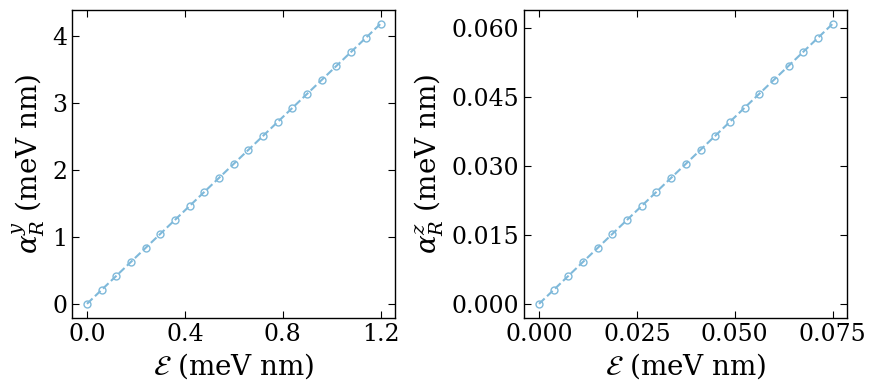

In [35]:
fig, axs = plt.subplots(
    1, 2,
    sharex="col",
    sharey="none",
    figsize=(10, 4)
)

plt.subplots_adjust(wspace=0.40, hspace=0.10)
ax_alpha_y = axs[0]
ax_alpha_z = axs[1]

ax_alpha_y.plot(
    Efield_split_y,
    alpha_y,
    marker="o",
    linestyle="--",
    color=blue_colors_split[0],
    # label="2nd Order",
    markersize=5,
    markerfacecolor="none",
    markeredgewidth=1.0,
    linewidth=1.5
)

ax_alpha_z.plot(
    Efield_split_z,
    alpha_z,
    marker="o",
    linestyle="--",
    color=blue_colors_split[0],
    # label="2nd Order",
    markersize=5,
    markerfacecolor="none",
    markeredgewidth=1.0,
    linewidth=1.5
)

ax_alpha_y.yaxis.set_major_locator(
    MaxNLocator(nbins=5, prune="upper")
)

ax_alpha_z.yaxis.set_major_locator(
    MaxNLocator(nbins=5)
)

ax_alpha_y.xaxis.set_major_locator(
    MaxNLocator(nbins=4)
)

ax_alpha_z.xaxis.set_major_locator(
    MaxNLocator(nbins=4)
)

ax_alpha_y.set_ylabel(r"$\alpha^y_R$ (meV nm)")
ax_alpha_y.set_xlabel(r"$\mathcal{E}$ (meV nm)")

ax_alpha_z.set_ylabel(r"$\alpha^z_R$ (meV nm)")
ax_alpha_z.set_xlabel(r"$\mathcal{E}$ (meV nm)")

save_name = f"combined_alpha_grid_N{N}_L{L}.pdf"
plt.savefig(save_name, dpi=300, bbox_inches="tight")

print("-"*30)

alpha_y_max = alpha_y.max()
alpha_z_max = alpha_z.max()
print("alpha_y_max : ", alpha_y_max.round(3), "meV nm")
print("alpha_z_max : ", alpha_z_max.round(3), "meV nm")

print("-"*30)

alpha_y_max_prime = (alpha_y[-1]*1000/Efield_split_y[-1])
alpha_z_max_prime = (alpha_z[-1]*1000/Efield_split_z[-1])

print("alpha_y_max' : ", alpha_y_max_prime.round(2), "meV nm^2/V")
print("alpha_z_max' : ", alpha_z_max_prime.round(2), "meV nm^2/V")

print("-"*30)
hbar = 6.582e-16 #eV s
m = 9.11e-31 #kgs
my_eff = 0.0672 #unit_less
mz_eff = 0.524 #unit_less
e0 = 1.602e-19 #C
unit_conversion = e0*1e21 #to_convert_into_nm
lso_y = hbar**2 * unit_conversion / (my_eff * m * alpha_y_max)
lso_z = hbar**2 * unit_conversion / (mz_eff * m * alpha_z_max)
print("spin-orbit length max: ", )
print("spin orbit length Y: ",lso_y.round(3),"nm")
print("spin orbit length Z: ", lso_z.round(3),"nm")

## 3. Si_Ge nanowire Kloeffel paper L = 10 nm

In [64]:

print("-"*30)
print("calculate alpha from given alpha_DR")
print("-"*30)
alpha_DR_bar = 8.4 #nm_e
E = 1.2 #V/um
alpha_R = alpha_DR_bar * E
alpha_R_prime = alpha_R/E*100
print("alpha_R: ", alpha_R)
print("alpha_R_prime: ",alpha_R_prime)
print("-"*30)



print("-"*30)
print("calculate alpha max frm fig_6")
print("-"*30)
#general constants
hbar = 6.582e-16 #eV s
m = 9.11e-31 #kgs
e0 = 1.602e-19 #C

#E_SO_max from Fig-6 is
# parameters 
E_so_max = 1.5 #meV
EField_max = 35 #V/um
m_eff = 0.067

# main formula
# E_SO = m_eff * alpha^2/(2*hbar^2)
# alpha = sqrt(2 * E_SO habr^2/ me_eff) meV.nm

alpha_Ge = np.sqrt(2 * E_so_max * hbar**2 * e0 * 1e21/ (m_eff * m))

print("alpha_max: ", alpha_Ge.round(3), "meV nm")
lso_ge = hbar**2 * unit_conversion / (m_eff * m * alpha_Ge)
print("soc length: ",lso_ge.round(2), "nm")


------------------------------
calculate alpha from given alpha_DR
------------------------------
alpha_R:  10.08
alpha_R_prime:  840.0
------------------------------
------------------------------
calculate alpha max frm fig_6
------------------------------
alpha_max:  58.405 meV nm
soc length:  19.47 nm
